In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from glob import glob
from tqdm import tqdm
import xarray as xr
import os, sys
import scipy
import pandas as pd
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from scipy import stats

from scipy import interpolate

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

from cinplaAnalysis.utils import *

%matplotlib inline

In [2]:
from cinplaAnalysis.icsd import StandardCSD, DeltaiCSD, StepiCSD

In [3]:
import matplotlib

font = {'size'   : 12}

matplotlib.rc('font', **font)

In [4]:
matplotlib.rcParams['savefig.pad_inches'] = 0

In [5]:
def plotFig(ax,csd,breaks=None,absmax=None,timeLimited=False,plotCB=False,xlabels=False,title=None):

    if breaks is not None:
        for b in breaks:
            ax.plot([0,3000],[b,b],c='k')

    if absmax is None:
        absmax = np.max(np.abs(csd))

    rms = np.mean(np.sqrt(csd**2))
    
    im = ax.imshow(np.array(csd)/rms, origin='lower',cmap='bwr_r',vmin=-10,vmax=10)#, vmin =-absmax,vmax=absmax, cmap='bwr_r')
    ax.axis(ax.axis('tight'))

    if plotCB:
        cb = plt.colorbar(im, ax=ax)
        cb.formatter.set_powerlimits((0,0))


    ax.set_yticklabels([])

    if xlabels:
        ax.set_xticks([0,50],labels=['0','50'])
        # ax.set_xlabel('Time (ms)')
    else:
        ax.set_xticklabels([])

    if timeLimited:
        ax.set_xlim([50,100])
    else:
        ax.set_xlim([0,50])

    if title:
        plt.title(title)

    plt.tight_layout()

In [6]:
def produce_iCSD(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.376 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.376 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_low_half = StepiCSD(**step_input_low_half)
    icsd_low_quarter = StepiCSD(**step_input_low_quarter)
    
    icsd_high_std = StandardCSD(**std_input_high)
    icsd_low_std = StandardCSD(**std_input_low)
    icsd_low_half_std = StandardCSD(**std_input_low_half)
    icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)

    return icsd_high

    

In [7]:
def produce_iCSD_all(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.376 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.376 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_low_half = StepiCSD(**step_input_low_half)
    icsd_low_quarter = StepiCSD(**step_input_low_quarter)
    
    icsd_high_std = StandardCSD(**std_input_high)
    icsd_low_std = StandardCSD(**std_input_low)
    icsd_low_half_std = StandardCSD(**std_input_low_half)
    icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)

    return icsd_high, icsd_low, icsd_low_half, icsd_low_quarter

In [8]:
def produce_sCSD(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.376 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.376 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_low_half = StepiCSD(**step_input_low_half)
    icsd_low_quarter = StepiCSD(**step_input_low_quarter)
    
    icsd_high_std = StandardCSD(**std_input_high)
    icsd_low_std = StandardCSD(**std_input_low)
    icsd_low_half_std = StandardCSD(**std_input_low_half)
    icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)

    return icsd_high_std

In [9]:
def produce_oCSD(data,lfp_idx,disk_fullDensity_idx):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    objective_disk_full_highRes = data[:,disk_fullDensity_idx] # oCSD, 20 um spacing

    # objective_disk_full_lowRes = np.zeros_like(totalLFPLowRes)
    # objective_disk_half_lowRes = np.zeros_like(totalLFPLowResHalf)
    # objective_disk_quarter_lowRes = np.zeros_like(totalLFPLowResQuarter)
    
    # for l in range(objective_disk_full_lowRes.shape[1]):
    #     if l == 0:
    #         objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l+1]
    #     elif l == objective_disk_full_lowRes.shape[1]-1:
    #         objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]
    #     else:
    #         objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]+.5*objective_disk_full_highRes[:,2*l+1]
    
    # for l in range(objective_disk_half_lowRes.shape[1]):
    #     if l == 0:
    #         objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
    #     elif l == objective_disk_half_lowRes.shape[1]-1:
    #         objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
    #     else:
    #         objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]
    
    # for l in range(objective_disk_quarter_lowRes.shape[1]):
    #     if l == 0:
    #         objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
    #     elif l == objective_disk_quarter_lowRes.shape[1]-1:
    #         objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
    #     else:
    #         objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]

    return objective_disk_full_highRes

In [10]:
def produce_oCSD_all(data,lfp_idx,disk_fullDensity_idx):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    objective_disk_full_highRes = data[:,disk_fullDensity_idx] # oCSD, 20 um spacing

    objective_disk_full_lowRes = np.zeros_like(totalLFPLowRes)
    objective_disk_half_lowRes = np.zeros_like(totalLFPLowResHalf)
    objective_disk_quarter_lowRes = np.zeros_like(totalLFPLowResQuarter)
    
    for l in range(objective_disk_full_lowRes.shape[1]):
        if l == 0:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l+1]
        elif l == objective_disk_full_lowRes.shape[1]-1:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]
        else:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]+.5*objective_disk_full_highRes[:,2*l+1]
    
    for l in range(objective_disk_half_lowRes.shape[1]):
        if l == 0:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
        elif l == objective_disk_half_lowRes.shape[1]-1:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
        else:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]
    
    for l in range(objective_disk_quarter_lowRes.shape[1]):
        if l == 0:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
        elif l == objective_disk_quarter_lowRes.shape[1]-1:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
        else:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]

    return objective_disk_full_highRes, objective_disk_full_lowRes, objective_disk_half_lowRes, objective_disk_quarter_lowRes

In [11]:
highResRerun = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/total.npy')


In [12]:
lfpIdx = np.arange(101)
csd500Idx = np.arange(101,202)
csd200Idx = np.arange(202,303)
csd50Idx = np.arange(303,404)
csd100Idx = np.arange(404,505)
csd20Idx = np.arange(505,606)

In [13]:
icsd_high_new_500, icsd_low_new_500, icsd_half_new_500, icsd_quarter_new_500 = produce_iCSD_all(highResRerun,lfpIdx,1000e-6*pq.m)
icsd_high_new_200 = produce_iCSD(highResRerun,lfpIdx,400E-6 * pq.m)
icsd_high_new_100 = produce_iCSD(highResRerun,lfpIdx,200E-6 * pq.m)
icsd_high_new_50 = produce_iCSD(highResRerun,lfpIdx,100E-6 * pq.m)
icsd_high_new_20 = produce_iCSD(highResRerun,lfpIdx,40E-6 * pq.m)

icsd_high_new_20, icsd_low_new_20, icsd_half_new_20, icsd_quarter_new_20 = produce_iCSD_all(highResRerun,lfpIdx,40e-6*pq.m)

In [14]:
sCsd_high_new = produce_sCSD(highResRerun,lfpIdx,40E-6 * pq.m)

In [15]:
ocsd_500, ocsd_low_500, ocsd_half_500, ocsd_quarter_500 = produce_oCSD_all(highResRerun,lfpIdx,csd500Idx)
ocsd_20, ocsd_low_20, ocsd_half_20, ocsd_quarter_20 = produce_oCSD_all(highResRerun,lfpIdx,csd20Idx)
ocsd_200 = produce_oCSD(highResRerun,lfpIdx,csd200Idx)
ocsd_100 = produce_oCSD(highResRerun,lfpIdx,csd100Idx)
ocsd_50 = produce_oCSD(highResRerun,lfpIdx,csd50Idx)
ocsd_20 = produce_oCSD(highResRerun,lfpIdx,csd20Idx)


In [16]:
nncsd = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_nncsd/total.npy') # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um


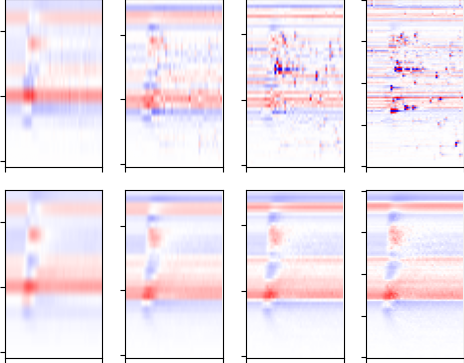

In [17]:
fig, axes = plt.subplots(2,4,figsize=(5,4))

plotFig(axes[0][0],icsd_quarter_new_500.get_csd())
plotFig(axes[0][1],icsd_half_new_500.get_csd())
plotFig(axes[0][2],icsd_low_new_500.get_csd())
plotFig(axes[0][3],icsd_high_new_500.get_csd())

plotFig(axes[1][0],ocsd_quarter_500.T)
plotFig(axes[1][1],ocsd_half_500.T)
plotFig(axes[1][2],ocsd_low_500.T)
plotFig(axes[1][3],ocsd_500.T)




In [18]:
correlations_high = []
correlations_low = []
correlations_half = []
correlations_quarter = []

for i in np.arange(50):
    correlations_high.append(np.corrcoef(icsd_high_new_500.get_csd()[:,i],ocsd_500.T[:,i])[0,1])
    correlations_low.append(np.corrcoef(icsd_low_new_500.get_csd()[:,i],ocsd_low_500.T[:,i])[0,1])
    correlations_half.append(np.corrcoef(icsd_half_new_500.get_csd()[:,i],ocsd_half_500.T[:,i])[0,1])
    correlations_quarter.append(np.corrcoef(icsd_quarter_new_500.get_csd()[:,i],ocsd_quarter_500.T[:,i])[0,1])


Text(0, 0.5, 'Correlation')

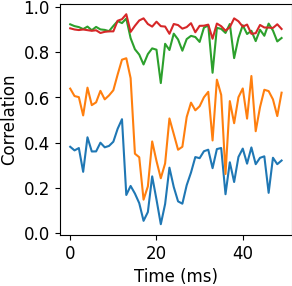

In [19]:
plt.figure(figsize=(3,3))
plt.plot(correlations_high)
plt.plot(correlations_low)
plt.plot(correlations_half)
plt.plot(correlations_quarter)

plt.xlabel('Time (ms)')
plt.ylabel('Correlation')


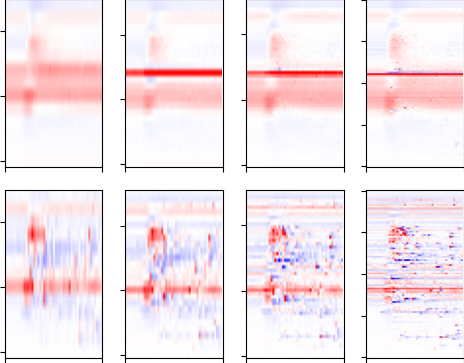

In [20]:
fig, axes = plt.subplots(2,4,figsize=(5,4))

plotFig(axes[0][0],icsd_quarter_new_20.get_csd())
plotFig(axes[0][1],icsd_half_new_20.get_csd())
plotFig(axes[0][2],icsd_low_new_20.get_csd())
plotFig(axes[0][3],icsd_high_new_20.get_csd())

plotFig(axes[1][0],ocsd_quarter_20.T)
plotFig(axes[1][1],ocsd_half_20.T)
plotFig(axes[1][2],ocsd_low_20.T)
plotFig(axes[1][3],ocsd_20.T)

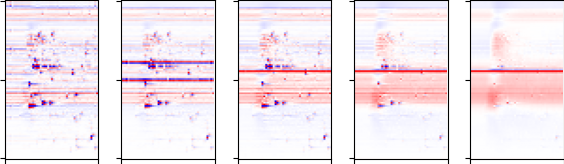

In [21]:
fig, axes = plt.subplots(1,5,figsize=(6,2))

plotFig(axes[0],icsd_high_new_500.get_csd())
plotFig(axes[1],icsd_high_new_200.get_csd())
plotFig(axes[2],icsd_high_new_100.get_csd())
plotFig(axes[3],icsd_high_new_50.get_csd())
plotFig(axes[4],icsd_high_new_20.get_csd())

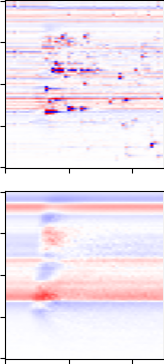

In [22]:
fig, axes = plt.subplots(2,1,figsize=(2,4))

plotFig(axes[0],icsd_high_new_500.get_csd())
plotFig(axes[1],ocsd_500.T)

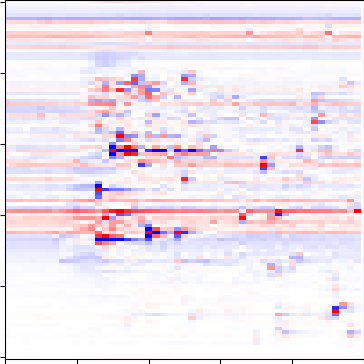

In [23]:
fig, axes = plt.subplots(1,1,figsize=(4,4))

plotFig(axes,sCsd_high_new.get_csd())


In [24]:
correlations_test_20 = []
for i in np.arange(50):
    correlations_test_20.append(np.corrcoef(icsd_high_new_20.get_csd()[:,i],ocsd_20.T[:,i])[0,1])

correlations_test_50 = []
for i in np.arange(50):
    correlations_test_50.append(np.corrcoef(icsd_high_new_50.get_csd()[:,i],ocsd_50.T[:,i])[0,1])

correlations_test_100 = []
for i in np.arange(50):
    correlations_test_100.append(np.corrcoef(icsd_high_new_100.get_csd()[:,i],ocsd_100.T[:,i])[0,1])

correlations_test_200 = []
for i in np.arange(50):
    correlations_test_200.append(np.corrcoef(icsd_high_new_200.get_csd()[:,i],ocsd_200.T[:,i])[0,1])

correlations_test_500 = []
for i in np.arange(50):
    correlations_test_500.append(np.corrcoef(icsd_high_new_500.get_csd()[:,i],ocsd_500.T[:,i])[0,1])

In [25]:
correlations_test_std_20 = []
for i in np.arange(50):
    correlations_test_std_20.append(np.corrcoef(sCsd_high_new.get_csd()[:,i],ocsd_20.T[:,i])[0,1])

correlations_test_std_50 = []
for i in np.arange(50):
    correlations_test_std_50.append(np.corrcoef(sCsd_high_new.get_csd()[:,i],ocsd_50.T[:,i])[0,1])

correlations_test_std_100 = []
for i in np.arange(50):
    correlations_test_std_100.append(np.corrcoef(sCsd_high_new.get_csd()[:,i],ocsd_100.T[:,i])[0,1])

correlations_test_std_200 = []
for i in np.arange(50):
    correlations_test_std_200.append(np.corrcoef(sCsd_high_new.get_csd()[:,i],ocsd_200.T[:,i])[0,1])

correlations_test_std_500 = []
for i in np.arange(50):
    correlations_test_std_500.append(np.corrcoef(sCsd_high_new.get_csd()[:,i],ocsd_500.T[:,i])[0,1])    

In [26]:
correlations_test_nn_20 = []
for i in np.arange(50):
    correlations_test_nn_20.append(np.corrcoef(nncsd.T[:,i],ocsd_20.T[1:-1,i])[0,1])

correlations_test_nn_50 = []
for i in np.arange(50):
    correlations_test_nn_50.append(np.corrcoef(nncsd.T[:,i],ocsd_50.T[1:-1,i])[0,1])

correlations_test_nn_100 = []
for i in np.arange(50):
    correlations_test_nn_100.append(np.corrcoef(nncsd.T[:,i],ocsd_100.T[1:-1,i])[0,1])

correlations_test_nn_200 = []
for i in np.arange(50):
    correlations_test_nn_200.append(np.corrcoef(nncsd.T[:,i],ocsd_200.T[1:-1,i])[0,1])

correlations_test_nn_500 = []
for i in np.arange(50):
    correlations_test_nn_500.append(np.corrcoef(nncsd.T[:,i],ocsd_500.T[1:-1,i])[0,1])

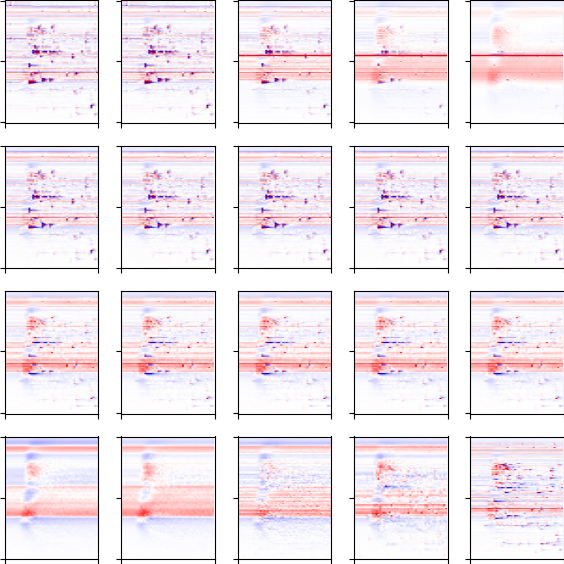

In [27]:
fig, axes = plt.subplots(4,5,figsize=(6,6))

plotFig(axes[0][0],icsd_high_new_500.get_csd())
plotFig(axes[0][1],icsd_high_new_500.get_csd())
plotFig(axes[0][2],icsd_high_new_100.get_csd())
plotFig(axes[0][3],icsd_high_new_50.get_csd())
plotFig(axes[0][4],icsd_high_new_20.get_csd())

plotFig(axes[1][0],sCsd_high_new.get_csd())
plotFig(axes[1][1],sCsd_high_new.get_csd())
plotFig(axes[1][2],sCsd_high_new.get_csd())
plotFig(axes[1][3],sCsd_high_new.get_csd())
plotFig(axes[1][4],sCsd_high_new.get_csd())

plotFig(axes[2][0],nncsd.T)
plotFig(axes[2][1],nncsd.T)
plotFig(axes[2][2],nncsd.T)
plotFig(axes[2][3],nncsd.T)
plotFig(axes[2][4],nncsd.T)

plotFig(axes[3][0],ocsd_500.T)
plotFig(axes[3][1],ocsd_200.T)
plotFig(axes[3][2],ocsd_100.T)
plotFig(axes[3][3],ocsd_50.T)
plotFig(axes[3][4],ocsd_20.T)

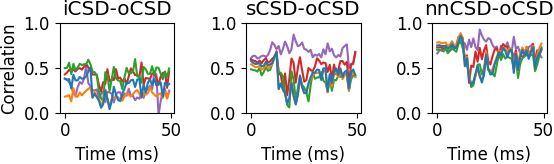

In [29]:
plt.figure(figsize=(6,2))
plt.subplot(131)
plt.title('iCSD-oCSD')
plt.plot(correlations_test_20,c='C4')
plt.plot(correlations_test_50,c='C3')
plt.plot(correlations_test_100,c='C2')
plt.plot(correlations_test_200,c='C1')
plt.plot(correlations_test_500,c='C0')
plt.xlabel('Time (ms)')
plt.ylabel('Correlation')
plt.ylim([0,1])

plt.subplot(132)
plt.title('sCSD-oCSD')
plt.plot(correlations_test_std_20,c='C4')
plt.plot(correlations_test_std_50,c='C3')
plt.plot(correlations_test_std_100,c='C2')
plt.plot(correlations_test_std_200,c='C1')
plt.plot(correlations_test_std_500,c='C0')
plt.xlabel('Time (ms)')
plt.ylim([0,1])

plt.subplot(133)
plt.title('nnCSD-oCSD')
plt.plot(correlations_test_nn_20,c='C4')
plt.plot(correlations_test_nn_50,c='C3')
plt.plot(correlations_test_nn_100,c='C2')
plt.plot(correlations_test_nn_200,c='C1')
plt.plot(correlations_test_nn_500,c='C0')
plt.ylim([0,1])
plt.xlabel('Time (ms)')

plt.tight_layout()

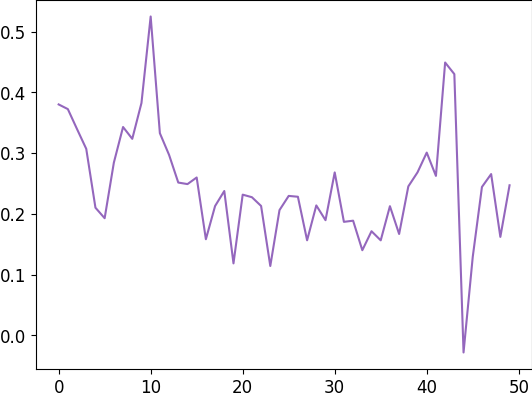

In [30]:
plt.figure()
plt.plot(correlations_test_20,c='C4')

In [31]:
np.mean(correlations_test_20)

np.float64(0.24512363226574382)

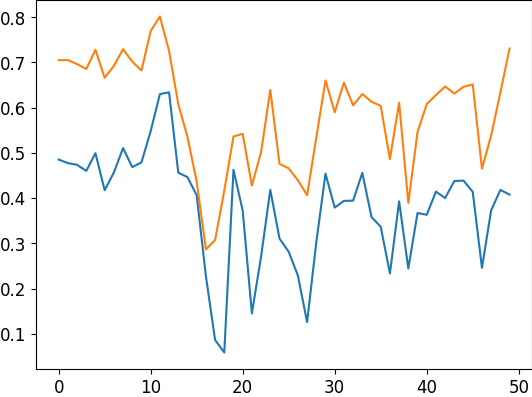

In [28]:
plt.figure()
plt.plot(correlations_test_std_100)
plt.plot(correlations_test_nn_100)

In [11]:
def getMeanCorrelation(icsd,ocsd):

    from scipy.stats import wasserstein_distance

    correlations = []
    distances = []
    icsdVal = icsd.get_csd()

    rms = np.mean(np.sqrt(icsdVal**2))

    icsdVal /=  rms

    rms = np.mean(np.sqrt(ocsd**2))

    ocsd /= rms

    for i in range(icsdVal.shape[1]):
        distances.append(wasserstein_distance(icsdVal[:,i],ocsd.T[:,i]))
        correlations.append(np.corrcoef(icsdVal[:,i],ocsd.T[:,i])[0,1])

    return np.mean(correlations), np.mean(distances)

In [12]:
def producePlotAndCorrelation(icsd,ocsd,icsdL4,ocsdL4,icsdL5,ocsdL5):

    fig, axes = plt.subplots(2,3,figsize=(6,4))

    plotFig(axes[0][0],icsd.get_csd())
    plotFig(axes[1][0],ocsd.T)
    
    plotFig(axes[0][1],icsdL4.get_csd())
    plotFig(axes[1][1],ocsdL4.T)
    
    plotFig(axes[0][2],icsdL5.get_csd())
    plotFig(axes[1][2],ocsdL5.T)

    correlations = [getMeanCorrelation(icsd,ocsd)[0],getMeanCorrelation(icsdL4,ocsdL4)[0],getMeanCorrelation(icsdL5,ocsdL5)[0]]
    distances = [getMeanCorrelation(icsd,ocsd)[1],getMeanCorrelation(icsdL4,ocsdL4)[1],getMeanCorrelation(icsdL5,ocsdL5)[1]]

    return correlations, distances

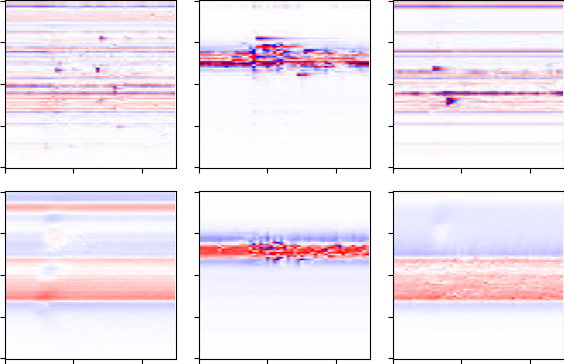

In [13]:
correlationsOrig500, distancesOrig500 = producePlotAndCorrelation(icsd_high_original_500,ocsd_original_500,icsd_L4_original_500,ocsd_l4_500,icsd_L5_original_500,ocsd_l5_500)


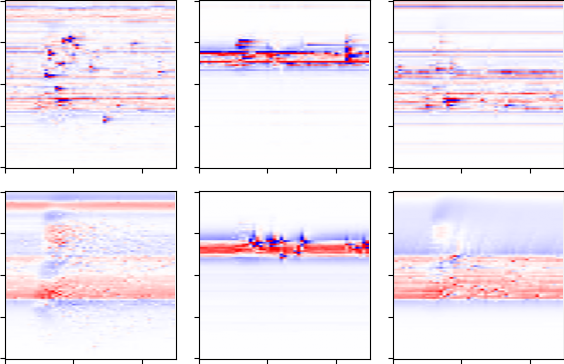

In [14]:
correlationsNoRecurrent500, distancesNoRecurrent500 = producePlotAndCorrelation(icsd_high_noRecurrent_500,ocsd_noRecurrent_500,icsd_L4_noRecurrent_500,ocsd_noRecurrent_l4_500,icsd_L5_noRecurrent_500,ocsd_noRecurrent_l5_500)


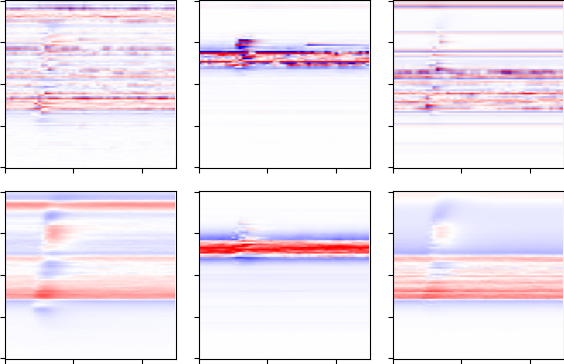

In [15]:
correlationsNoActive500, distancesNoActive500 = producePlotAndCorrelation(icsd_high_NoActive_500,ocsd_noActive_500,icsd_L4_NoActive_500,ocsd_noActive_l4_500,icsd_L5_NoActive_500,ocsd_noActive_l5_500)


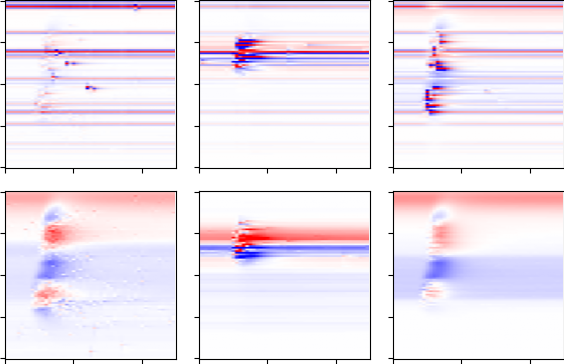

In [16]:
correlationsNoNoise500, distancesNoNoise500 = producePlotAndCorrelation(icsd_high_NoNoise_500,ocsd_noNoise_500,icsd_L4_NoNoise_500,ocsd_noNoise_l4_500,icsd_L5_NoNoise_500,ocsd_noNoise_l5_500)


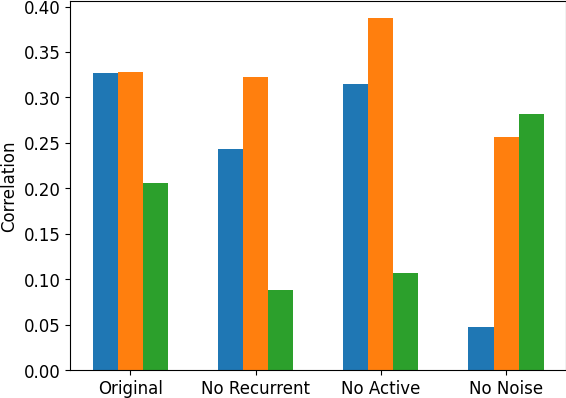

In [28]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, correlations500[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Correlation')

plt.show()

In [ ]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, distances20[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Wasserstein distance')

plt.show()

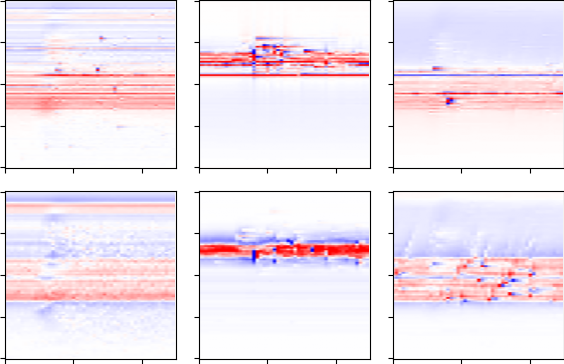

In [19]:
correlationsOrig100, distancesOrig100 = producePlotAndCorrelation(icsd_high_original_100,ocsd_original_100,icsd_L4_original_100,ocsd_l4_100,icsd_L5_original_100,ocsd_l5_100)


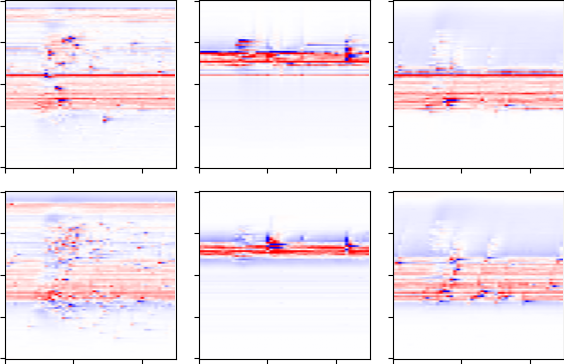

In [20]:
correlationsNoRecurrent100, distancesNoRecurrent100 = producePlotAndCorrelation(icsd_high_noRecurrent_100,ocsd_noRecurrent_100,icsd_L4_noRecurrent_100,ocsd_noRecurrent_l4_100,icsd_L5_noRecurrent_100,ocsd_noRecurrent_l5_100)


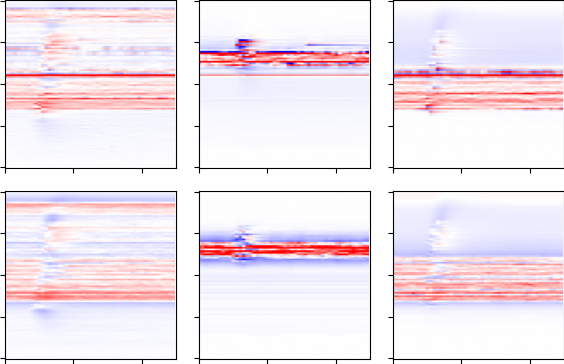

In [21]:
correlationsNoActive100, distancesNoActive100 = producePlotAndCorrelation(icsd_high_NoActive_100,ocsd_noActive_100,icsd_L4_NoActive_100,ocsd_noActive_l4_100,icsd_L5_NoActive_100,ocsd_noActive_l5_100)


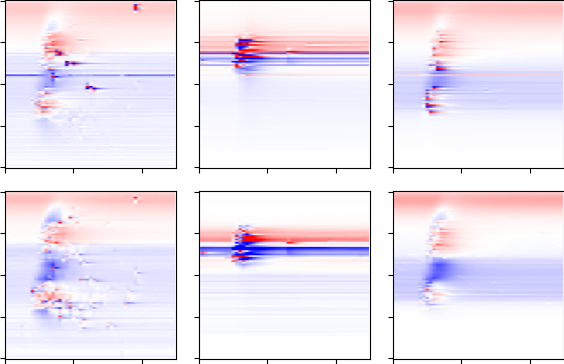

In [22]:
correlationsNoNoise100, distancesNoNoise100 = producePlotAndCorrelation(icsd_high_NoNoise_100,ocsd_noNoise_100,icsd_L4_NoNoise_100,ocsd_noNoise_l4_100,icsd_L5_NoNoise_100,ocsd_noNoise_l5_100)


PermissionError: [Errno 13] Permission denied: '/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/explainPriorWork.png'

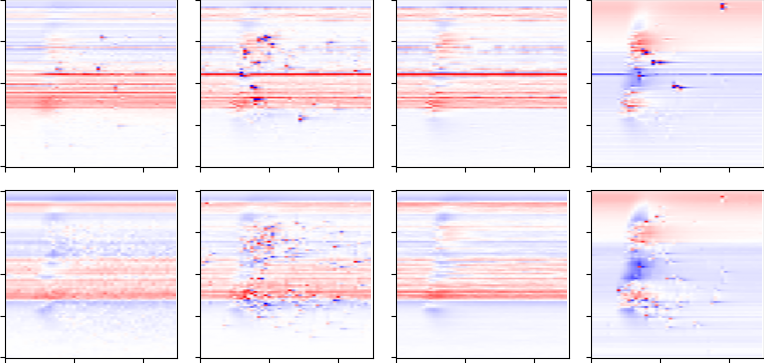

In [29]:
fig, axes = plt.subplots(2,4,figsize=(8,4))

plotFig(axes[0][0],icsd_high_original_100.get_csd())
plotFig(axes[1][0],ocsd_original_100.T)

plotFig(axes[0][1],icsd_high_noRecurrent_100.get_csd())
plotFig(axes[1][1],ocsd_noRecurrent_100.T)

plotFig(axes[0][2],icsd_high_NoActive_100.get_csd())
plotFig(axes[1][2],ocsd_noActive_100.T)

plotFig(axes[0][3],icsd_high_NoNoise_100.get_csd())
plotFig(axes[1][3],ocsd_noNoise_100.T)

plt.tight_layout()

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/explainPriorWork.png',dpi=600)


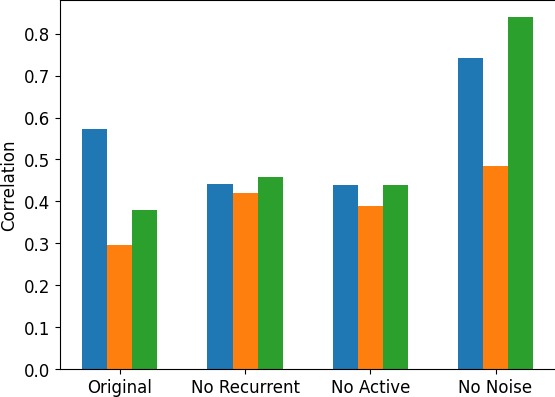

In [47]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, correlations100[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Correlation')

plt.show()

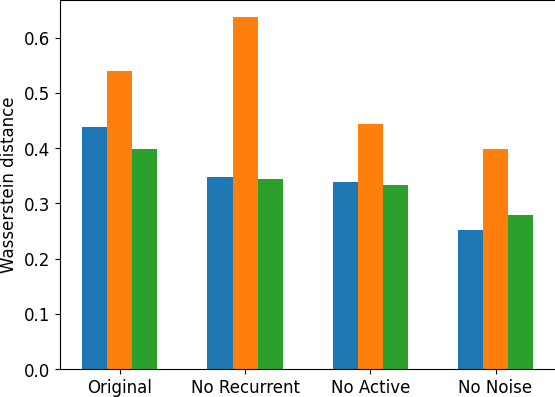

In [48]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, distances100[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Wasserstein distance')

plt.show()

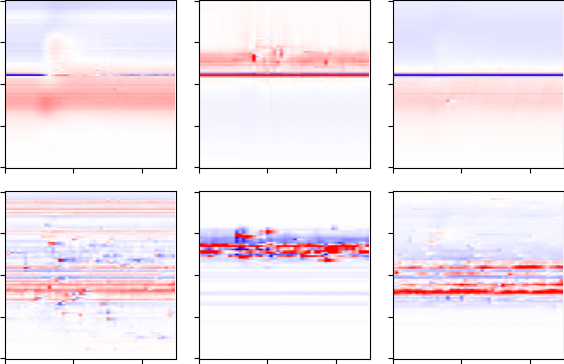

In [23]:
correlationsOrig20, distancesOrig20 = producePlotAndCorrelation(icsd_high_original_20,ocsd_original_20,icsd_L4_original_20,ocsd_l4_20,icsd_L5_original_20,ocsd_l5_20)


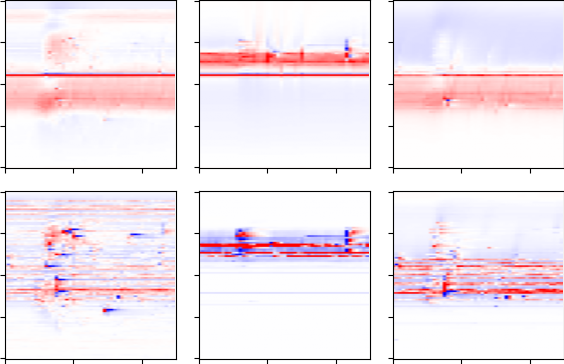

In [24]:
correlationsNoRecurrent20, distancesNoRecurrent20 = producePlotAndCorrelation(icsd_high_noRecurrent_20,ocsd_noRecurrent_20,icsd_L4_noRecurrent_20,ocsd_noRecurrent_l4_20,icsd_L5_noRecurrent_20,ocsd_noRecurrent_l5_20)


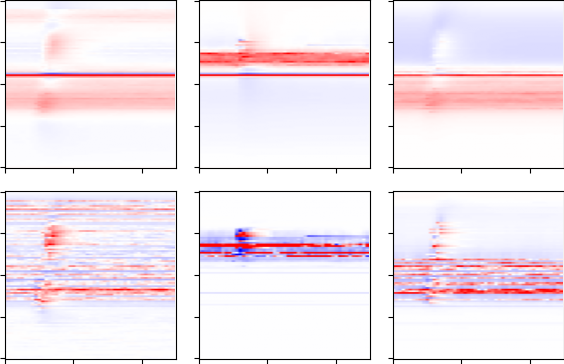

In [25]:
correlationsNoActive20, distancesNoActive20 = producePlotAndCorrelation(icsd_high_NoActive_20,ocsd_noActive_20,icsd_L4_NoActive_20,ocsd_noActive_l4_20,icsd_L5_NoActive_20,ocsd_noActive_l5_20)



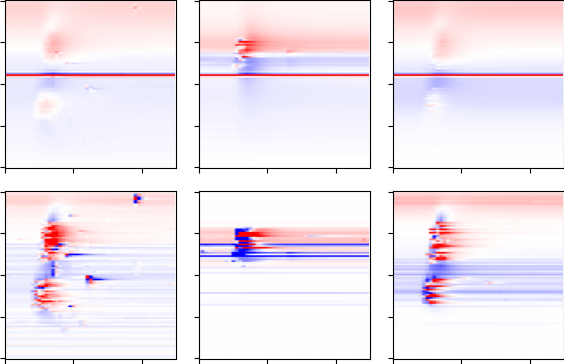

In [26]:
correlationsNoNoise20, distancesNoNoise20 = producePlotAndCorrelation(icsd_high_NoNoise_20,ocsd_noNoise_20,icsd_L4_NoNoise_20,ocsd_noNoise_l4_20,icsd_L5_NoNoise_20,ocsd_noNoise_l5_20)


In [27]:
correlations500 = np.array([correlationsOrig500, correlationsNoRecurrent500, correlationsNoActive500, correlationsNoNoise500])
correlations100 = np.array([correlationsOrig100, correlationsNoRecurrent100, correlationsNoActive100, correlationsNoNoise100])
correlations20 = np.array([correlationsOrig20, correlationsNoRecurrent20, correlationsNoActive20, correlationsNoNoise20])

distances500 = np.array([distancesOrig500, distancesNoRecurrent500, distancesNoActive500, distancesNoNoise500])
distances100 = np.array([distancesOrig100, distancesNoRecurrent100, distancesNoActive100, distancesNoNoise100])
distances20 = np.array([distancesOrig20, distancesNoRecurrent20, distancesNoActive20, distancesNoNoise20])


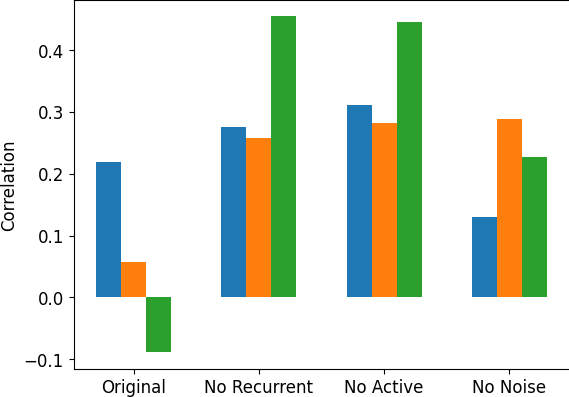

In [35]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, correlations20[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Correlation')

plt.show()

In [28]:
for f in correlations500:
    print(f)

[np.float64(0.2752671015621234), np.float64(0.3284058440580628), np.float64(0.20644730077464055)]
[np.float64(0.24354113253593698), np.float64(0.32260586930556967), np.float64(0.0880944185359527)]
[np.float64(0.24354113253593698), np.float64(0.38710142215979104), np.float64(0.10673677708919849)]
[np.float64(0.047728169403724416), np.float64(0.25602402211449593), np.float64(0.2814694035179071)]


In [29]:
for f in correlations20:
    print(f)

[np.float64(0.21891397057664397), np.float64(0.05664435362826472), np.float64(-0.08915088554564925)]
[np.float64(0.27614694674365237), np.float64(0.25849949703259484), np.float64(0.4547790912642513)]
[np.float64(0.31219379218221016), np.float64(0.2826921516221745), np.float64(0.4461597521575362)]
[np.float64(0.1301064764045144), np.float64(0.2881474621050847), np.float64(0.22661532839109277)]


In [30]:
for f in distances20:
    print(f)

[np.float64(0.5488986452327381), np.float64(0.9883529054511604), np.float64(0.8842026219278981)]
[np.float64(0.6761325566431411), np.float64(0.9194639740296217), np.float64(0.6229058859282423)]
[np.float64(0.6864241820119155), np.float64(0.9037705480001875), np.float64(0.608288553514378)]
[np.float64(0.7389762257339878), np.float64(1.007470140901826), np.float64(0.6167189239219502)]


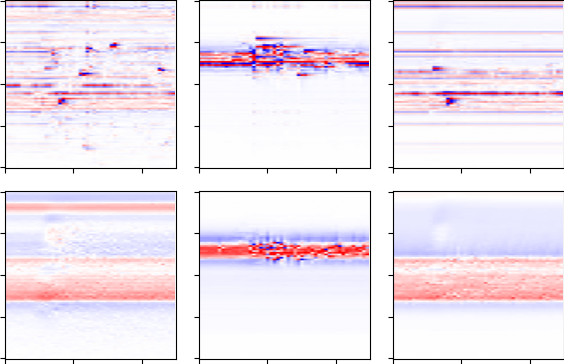

In [92]:
fig, axes = plt.subplots(2,3,figsize=(6,4))

plotFig(axes[0][0],icsd_high_original_500.get_csd())
plotFig(axes[1][0],ocsd_original_500.T)

plotFig(axes[0][1],icsd_L4_original_500.get_csd())
plotFig(axes[1][1],ocsd_l4_500.T)

plotFig(axes[0][2],icsd_L5_original_500.get_csd())
plotFig(axes[1][2],ocsd_l5_500.T)



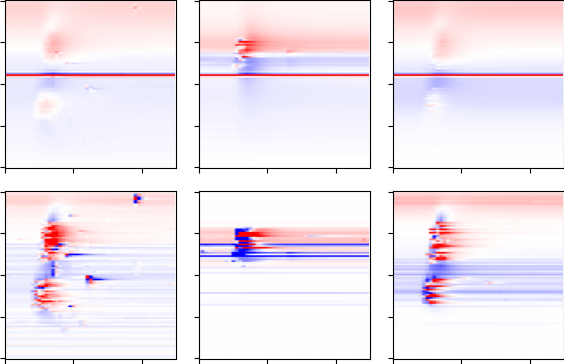

In [78]:
fig, axes = plt.subplots(2,3,figsize=(6,4))

plotFig(axes[0][0],icsd_high_NoNoise_20.get_csd())
plotFig(axes[1][0],ocsd_noNoise_20.T)

plotFig(axes[0][1],icsd_L4_NoNoise_20.get_csd())
plotFig(axes[1][1],ocsd_noNoise_l4_20.T)

plotFig(axes[0][2],icsd_L5_NoNoise_20.get_csd())
plotFig(axes[1][2],ocsd_noNoise_l5_20.T)

In [114]:
ocsd_noNoise_l4_20.T.shape

(101, 50)

In [84]:
getMeanCorrelation(icsd_L4_NoNoise_20,ocsd_noNoise_l4_20)

np.float64(0.6440737308366242)

In [85]:
getMeanCorrelation(icsd_L5_NoNoise_20,ocsd_noNoise_l5_20)

np.float64(0.6133076645043712)

In [115]:
getMeanCorrelation(icsd_high_NoNoise_500,ocsd_noNoise_500)

np.float64(0.5238640841478382)

In [20]:
### Calculates correlations between iCSD and oCSD for all electrode spacings

correlations_high_stim = []
correlations_low_stim = []
correlations_low_half_stim = []
correlations_low_quarter_stim = []

for i in np.arange(1500,1550):
    correlations_high_stim.append(np.corrcoef(icsd_high.get_csd()[:,i],objective_disk_full_highRes.T[:,i])[0,1])
    correlations_low_stim.append(np.corrcoef(icsd_low.get_csd()[:,i],objective_disk_full_lowRes.T[:,i])[0,1])
    correlations_low_half_stim.append(np.corrcoef(icsd_low_half.get_csd()[:,i],objective_disk_half_lowRes.T[:,i])[0,1])
    correlations_low_quarter_stim.append(np.corrcoef(icsd_low_quarter.get_csd()[:,i],objective_disk_quarter_lowRes.T[:,i])[0,1])


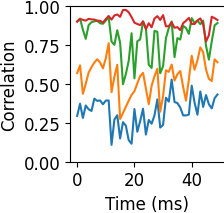

In [21]:
### Plots Figure 2b

plt.figure(figsize=(2.5,2.5))
plt.plot(correlations_high_stim,c='C0')
plt.plot(correlations_low_stim,c='C1')
plt.plot(correlations_low_half_stim,c='C2')
plt.plot(correlations_low_quarter_stim,c='C3')

plt.ylim([0,1])
plt.xlabel('Time (ms)')
plt.ylabel('Correlation')
plt.tight_layout()
# plt.savefig('figures/correlations.png',dpi=300)

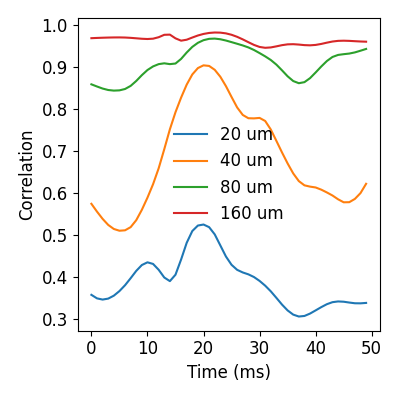

In [25]:
### Plots Figure 2b again, but with a legend

plt.figure(figsize=(4,4))
plt.plot(correlations_high_stim,c='C0',linestyle=None)
plt.plot(correlations_low_stim,c='C1',linestyle=None)
plt.plot(correlations_low_half_stim,c='C2',linestyle=None)
plt.plot(correlations_low_quarter_stim,c='C3',linestyle=None)

# plt.plot(correlations_high_rest,'--',c='C0')
# plt.plot(correlations_low_rest,'--',c='C1')
# plt.plot(correlations_low_half_rest,'--',c='C2')
# plt.plot(correlations_low_quarter_rest,'--',c='C3')

plt.legend(['20 um', '40 um','80 um','160 um'],framealpha=0)
plt.xlabel('Time (ms)')
plt.ylabel('Correlation')
plt.tight_layout()
plt.savefig('figures/correlations_legend.png',dpi=300)